# Predição de Vendas com Regressão Linear Múltipla

## Projeto de Modelagem Preditiva

### Objetivo

Desenvolver um modelo de Regressão Linear Múltipla para prever as vendas com base nos investimentos em publicidade.



# 1. Importação das Bibliotecas

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats

# 2. Carregamento da Base de Dados

In [5]:
df = pd.read_csv('propaganda (2) (1).csv')

### Visualização Inicial dos Dados

In [6]:
df.head()

,TV,Radio,Jornal,Vendas
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# 3. Análise Descritiva

## Estrutura da Base de Dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Radio   200 non-null    float64
 2   Jornal  200 non-null    float64
 3   Vendas  200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Estatísticas Descritivas

In [ ]:
df.describe()

,TV,Radio,Jornal,Vendas
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Verificação de Valores Ausentes

In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Jornal,0
Vendas,0


## Distribuição das Variáveis

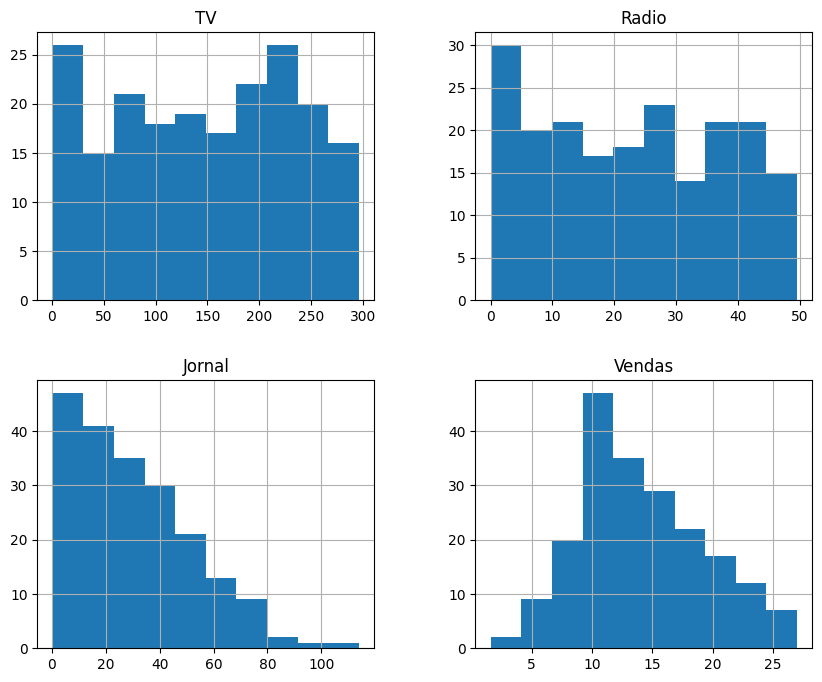

In [ ]:
df.hist(figsize=(10,8))
plt.show()

### Interpretação da Análise Descritiva

A base de dados possui 200 observações e 4 variáveis numéricas: TV, Radio, Jornal e Vendas.

Não foram identificados valores ausentes, indicando boa qualidade dos dados para aplicação de modelos estatísticos.

As variáveis apresentam variabilidade adequada para análise de regressão linear múltipla, não sendo observados problemas que comprometam a modelagem.

Dessa forma, a base encontra-se apta para as etapas de correlação, covariância e construção do modelo preditivo.

# 4. Correlação e Covariância

In [8]:
correlacao = df.corr()
correlacao

,TV,Radio,Jornal,Vendas
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Jornal,0.056648,0.354104,1.000000,0.228299
Vendas,0.782224,0.576223,0.228299,1.000000


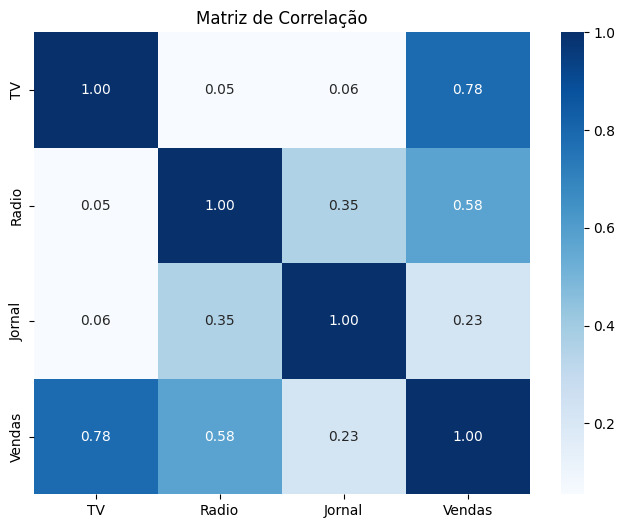

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

In [22]:
covariancia = df.cov()
covariancia

,TV,Radio,Jornal,Vendas
TV,7370.949893,69.862492,105.919452,350.390195
Radio,69.862492,220.427743,114.496979,44.635688
Jornal,105.919452,114.496979,474.308326,25.941392
Vendas,350.390195,44.635688,25.941392,27.221853


### Interpretação da Correlação e Covariância

A análise de correlação demonstrou que a variável TV apresenta a maior associação com as vendas, com coeficiente de correlação igual a 0,782, indicando uma relação positiva forte.

A variável Radio também apresentou relação positiva com as vendas (0,576), porém com intensidade moderada. Já a variável Jornal apresentou correlação fraca com a variável resposta (0,228), sugerindo menor influência sobre as vendas.

A análise de covariância confirmou a mesma tendência observada na correlação. A variável TV apresentou a maior covariância com as vendas (350,39), seguida por Radio (44,64) e Jornal (25,94), indicando que os investimentos em TV tendem a variar conjuntamente com as vendas em maior intensidade.

As correlações entre as variáveis explicativas foram relativamente baixas, indicando ausência de relações lineares fortes entre elas. Esse resultado sugere menor risco de problemas de multicolinearidade no modelo de regressão.

De forma geral, os resultados indicam que os investimentos em TV e Radio tendem a exercer maior influência sobre as vendas quando comparados aos investimentos em Jornal.

# 5. Construção do Modelo de Regressão Linear Múltipla

In [15]:
X = df[['TV', 'Radio', 'Jornal']]
y = df['Vendas']

X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        15:47:46   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

### Interpretação do Modelo de Regressão

O modelo de regressão linear múltipla apresentou coeficiente de determinação (R²) igual a 0,897, indicando que aproximadamente 89,7% da variação das vendas pode ser explicada pelas variáveis TV, Radio e Jornal.

O teste F apresentou valor-p praticamente nulo (Prob(F-statistic) < 0,05), demonstrando que o modelo é estatisticamente significativo.

A variável TV apresentou coeficiente positivo de 0,0458 e significância estatística (p < 0,05), indicando influência positiva sobre as vendas.

A variável Radio também apresentou coeficiente positivo de 0,1885 e significância estatística (p < 0,05), demonstrando impacto positivo nas vendas.

Por outro lado, a variável Jornal apresentou coeficiente negativo muito próximo de zero e valor-p igual a 0,860, indicando ausência de significância estatística. Dessa forma, não há evidências de que os investimentos em Jornal exerçam influência relevante sobre as vendas nesta base de dados.

Os resultados sugerem que TV e Radio são os principais fatores explicativos das vendas, enquanto Jornal apresenta baixa contribuição para o modelo.

# 6. Análise de Resíduos

In [16]:
previsoes = modelo.predict(X)
residuos = y - previsoes

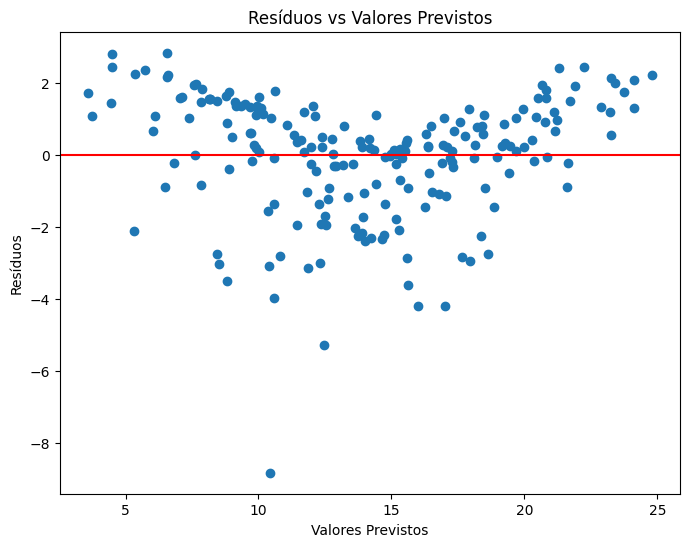

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(previsoes, residuos)

plt.axhline(y=0, color='red')

plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Previstos')

plt.show()

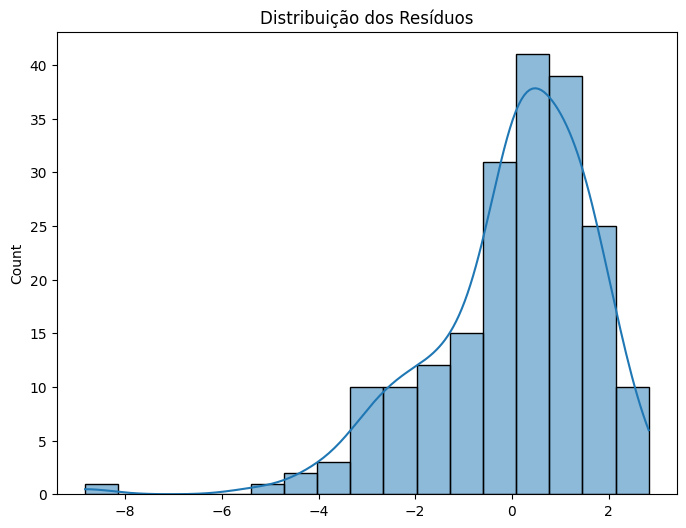

In [18]:
plt.figure(figsize=(8,6))

sns.histplot(residuos, kde=True)

plt.title('Distribuição dos Resíduos')

plt.show()

In [19]:
stats.shapiro(residuos)

ShapiroResult(statistic=np.float64(0.9176652036187539), pvalue=np.float64(3.938571556266683e-09))

### Interpretação da Análise de Resíduos

A análise gráfica dos resíduos mostrou concentração dos erros em torno da linha zero, indicando que o modelo consegue representar adequadamente a maior parte da variação observada nas vendas.

O histograma dos resíduos apresentou distribuição aproximadamente centrada em zero, embora seja possível observar assimetria e alguns valores extremos.

O teste de normalidade de Shapiro-Wilk apresentou valor-p inferior a 0,05, indicando rejeição da hipótese de normalidade dos resíduos. Dessa forma, os resíduos não seguem perfeitamente uma distribuição normal.

Apesar dessa limitação, o modelo apresentou elevado poder explicativo (R² = 0,897) e coeficientes estatisticamente significativos para as variáveis TV e Radio, demonstrando bom desempenho preditivo para a base analisada.

# 7. Análise de Multicolinearidade

In [20]:
vif = pd.DataFrame()

vif["Variável"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Variável,VIF
0,const,6.848900
1,TV,1.004611
2,Radio,1.144952
3,Jornal,1.145187


### Interpretação da Análise de Multicolinearidade

A análise de multicolinearidade foi realizada por meio do Fator de Inflação da Variância (VIF).

As variáveis TV, Radio e Jornal apresentaram valores de VIF próximos de 1, indicando ausência de correlações elevadas entre as variáveis explicativas.

Nenhuma variável apresentou VIF superior a 5, valor normalmente utilizado como referência para identificação de problemas de multicolinearidade.

Dessa forma, conclui-se que as variáveis independentes podem permanecer no modelo sem comprometer a estabilidade das estimativas dos coeficientes da regressão.

# 8. Análise do Modelo

### Conclusão da Análise do Modelo

O modelo de regressão linear múltipla apresentou desempenho satisfatório para previsão das vendas, alcançando coeficiente de determinação (R²) igual a 0,897. Isso indica que aproximadamente 89,7% da variação das vendas pode ser explicada pelas variáveis TV, Radio e Jornal.

A análise de correlação demonstrou que os investimentos em TV possuem a maior associação com as vendas, seguidos pelos investimentos em Radio. A variável Jornal apresentou baixa correlação com a variável resposta e não demonstrou significância estatística no modelo.

Os testes realizados indicaram ausência de problemas de multicolinearidade, uma vez que todas as variáveis apresentaram valores de VIF próximos de 1.

A análise dos resíduos mostrou erros concentrados próximos de zero, sugerindo bom ajuste do modelo aos dados observados. Embora o teste de normalidade tenha indicado que os resíduos não seguem perfeitamente uma distribuição normal, o modelo apresentou elevado poder explicativo e coeficientes consistentes para as variáveis mais relevantes.

Dessa forma, conclui-se que o modelo é adequado para estimar as vendas a partir dos investimentos em propaganda, sendo TV e Radio os principais fatores associados ao aumento das vendas.

# Conclusão Final

A análise exploratória dos dados demonstrou que a base apresenta boa qualidade, ausência de valores ausentes e características adequadas para aplicação de técnicas de regressão linear múltipla.

A análise de correlação indicou que os investimentos em TV e Radio possuem maior associação com as vendas, enquanto a variável Jornal apresentou relação mais fraca com a variável resposta.

O modelo de regressão linear múltipla apresentou elevado poder explicativo, com coeficiente de determinação (R²) de aproximadamente 0,897, indicando que cerca de 89,7% da variação das vendas pode ser explicada pelos investimentos em propaganda.

A análise dos resíduos indicou que o modelo apresenta bom ajuste aos dados, embora a hipótese de normalidade dos resíduos não tenha sido totalmente atendida segundo o teste de Shapiro-Wilk.

A análise de multicolinearidade demonstrou ausência de problemas relevantes entre as variáveis explicativas, garantindo maior confiabilidade às estimativas obtidas.

Dessa forma, conclui-se que o modelo desenvolvido é adequado para previsão de vendas com base nos investimentos em propaganda, destacando principalmente a influência dos investimentos em TV e Radio sobre os resultados obtidos.